# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Rows: 30,000 | Columns: 44 | Clients: 32
                          count   median     mean       max       std
impressions_90d         30000.0   731.00  5200.37  517715.0  16838.02
clicks_90d              30000.0     1.00    16.10    4178.0     75.08
sessions_90d            30000.0     7.00    37.07    4345.0    107.07
pageviews_90d           30000.0     8.00    49.94    5998.0    152.10
scroll_events_90d       30000.0     1.00     4.03    2605.0     22.34
ai_sessions_90d         30000.0     0.00     0.20      64.0      1.36
ctr                     30000.0     0.07     0.51     100.0      3.28
avg_position            30000.0    10.80    16.34     245.0     15.22
word_count              22301.0  2877.00  3107.76    9546.0   1452.38
content_age_days        30000.0   236.00   256.17     564.0    132.71
days_since_last_update  30000.0    20.00    46.10     373.0     42.08

Note: every 90-day total column has mean >> median — classic heavy tails (a few giants, a long tail).


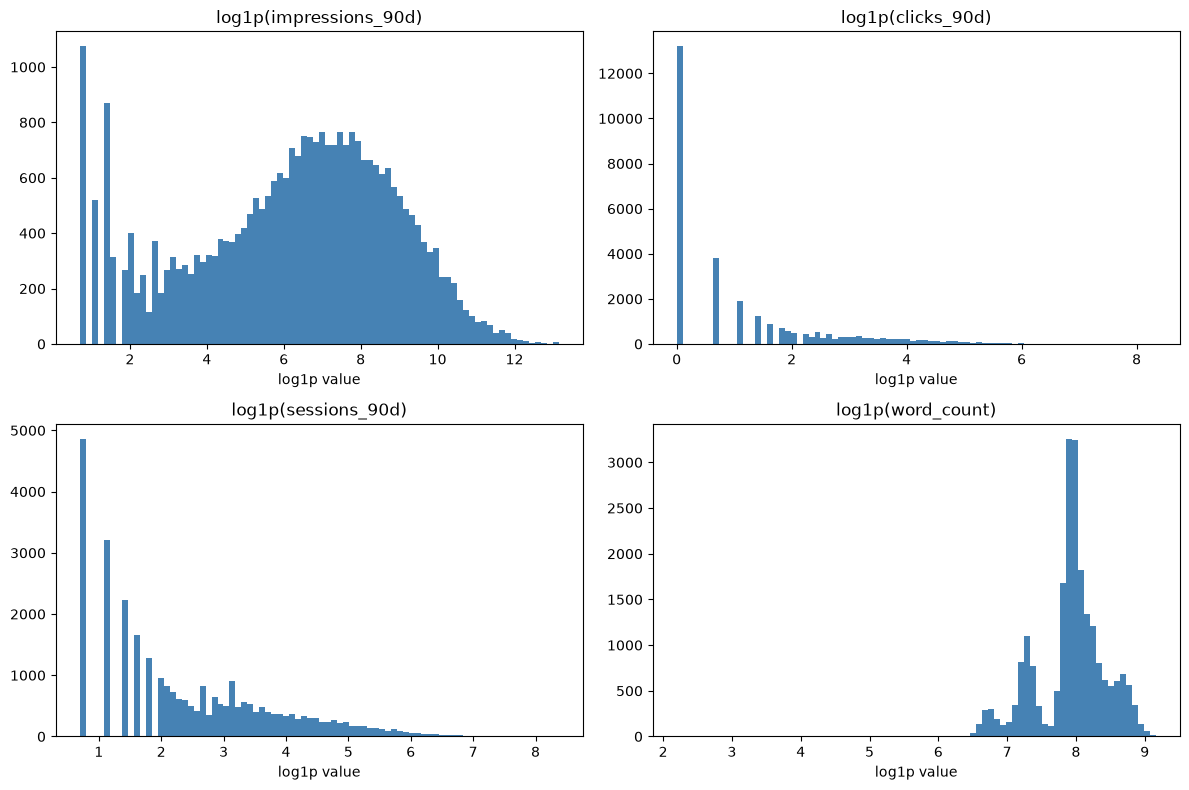

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seed for stable plotting
np.random.seed(42)

# Load the starter data (30k pages, 32 clients)
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Clients: {df['client_id'].nunique()}")

# A row is one content page; define the proxy label once
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

# Summary of key fields: count / median / mean / max. Medians are the honest center here.
traffic_cols = ["impressions_90d", "clicks_90d", "sessions_90d", "pageviews_90d",
               "scroll_events_90d", "ai_sessions_90d", "ctr", "avg_position",
               "word_count", "content_age_days", "days_since_last_update"]

summary = df[traffic_cols].agg(["count", "median", "mean", "max", "std"]).T
print(summary.round(2).to_string())
print()
print("Note: every 90-day total column has mean >> median — classic heavy tails (a few giants, a long tail).")

# Log-scaled histograms so the long tail is actually visible
cols = ["impressions_90d", "clicks_90d", "sessions_90d", "word_count"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cols):
    ax.hist(np.log1p(df[col].dropna().values), bins=80, color="steelblue", edgecolor="none")
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("log1p value")
plt.tight_layout()
plt.show()

Plain numbers first. impressions, clicks and sessions are all badly right-skewed — the median impressions is 731 while the mean is 5,200, so a handful of big pages pull the average way up while most pages get almost nothing. That immediately told me not to trust plain (Pearson) correlations on the raw totals; the giants would run the whole show. So everything below uses grouped medians/rates and log-scaled views instead.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [12]:
def verdict_table(groups, metric):
    """Minimal grouped-table printer; every row carries its n."""
    rows = []
    for label, g in groups:
        rows.append({"group": label, "n": len(g),
                     metric: float(g[metric].median()) if g[metric].notna().any() else np.nan})
    return pd.DataFrame(rows)

Signal #1 — "Longer pages get more traffic"

Claim: longer pages bring in more traffic. Test: median 90-day impressions per word_count_tier. One trap from the dictionary — ~7.7k rows have a blank word count, and that missingness follows content_type. So instead of quietly dropping them I keep them as their own bucket, front and center.

In [13]:
wc = df.copy()
wc["word_count_tier"] = wc["word_count_tier"].fillna("blank")

order = ["<1000", "1000-2000", "2000-3500", "3500+", "blank"]
t1 = verdict_table(wc.groupby("word_count_tier", dropna=False), "impressions_90d")
t1 = t1.set_index("group").reindex(order).reset_index()

print("Median impressions_90d by word_count_tier")
print(t1.round(0).to_string(index=False))
print()
# Huge ratio from tiny cells is noise; confirm floors before believing any row
below = t1[t1["n"] < 50]
print(f"Rows below the n=50 floor: {len(below)}")
print(f"Row-to-row spread is >5x; the <1000 tier rests on n={int(t1.loc[t1['group']=='<1000', 'n'][0])} — above the floor.")
# Cross-check: does the same ordering hold for clicks and CTR? (signal should survive a second slice)
wc2 = wc[wc["word_count_tier"] != "blank"]
t1b = verdict_table(wc2.groupby("word_count_tier"), "clicks_90d")
t1c = verdict_table(wc2.groupby("word_count_tier"), "ctr")
comb = t1b[['group', 'clicks_90d']].merge(t1c, on='group')
order2 = [g for g in order if g != "blank"]
print(comb.set_index("group").reindex(order2).round(3).to_string())
print()
print("Impressions rise monotonically with length; clicks/CTR do NOT keep climbing past 2000-3500 words.")

Median impressions_90d by word_count_tier
    group     n  impressions_90d
    <1000   973              4.0
1000-2000  3780            172.0
2000-3500 11263            997.0
    3500+  6285           1340.0
    blank  7699            878.0

Rows below the n=50 floor: 0
Row-to-row spread is >5x; the <1000 tier rests on n=973 — above the floor.
           clicks_90d      n   ctr
group                             
<1000             0.0    973  0.00
1000-2000         0.0   3780  0.00
2000-3500         2.0  11263  0.14
3500+             1.0   6285  0.06

Impressions rise monotonically with length; clicks/CTR do NOT keep climbing past 2000-3500 words.


Verdict #1: CONFIRMED for impressions, but MIXED once you look past that. Longer articles really do get seen more — median impressions climb 4 → 172 → 997 → 1,340 as length grows. But clicks and CTR don't keep climbing; they top out in the 2000-3500 bucket and dip again for 3500+. So length buys you eyeballs, not a better click-through. Every bucket sits comfortably above the n=50 floor.

Signal #2 — "Pages ranking higher get clicked more"

Claim: pages higher up the results get clicked more. Test: median CTR by position_tier. Two cleaning steps first: rows where avg_position is 0 are "no data", not "rank zero", so they go — and I only keep pages with at least 1,000 impressions, because otherwise the median gets drowned out by near-zero-traffic pages.

In [14]:
pos = df[(df["avg_position"] > 0) & (df["impressions_90d"] >= 1000)].copy()
order = ["top_3", "page_1", "striking", "page_3_5", "deep"]
t2 = verdict_table(pos.groupby("position_tier", dropna=False), "ctr")
t2 = t2.set_index("group").reindex(order).reset_index()

print("Median CTR (%) by position_tier")
print(t2.round(3).to_string(index=False))
print()
print(f"Kept {len(pos):,} rows with a real position AND >=1000 impressions (the zero-click/no-data noise is dropped).")
# Same check but by grouped median rank, on a second bucketation for the verification slice
rank_check = df[(df["avg_position"] > 0) & (df["impressions_90d"] >= 1000)].copy()
rank_check["rank_bucket"] = pd.cut(rank_check["avg_position"], bins=[0, 3, 10, 20, 30, 60], include_lowest=True)
t2b = verdict_table(rank_check.groupby("rank_bucket"), "ctr")
print(t2b.round(3).to_string(index=False))

Median CTR (%) by position_tier
   group    n  ctr
   top_3  394 0.23
  page_1 6156 0.24
striking 3448 0.19
page_3_5 3325 0.10
    deep  189 0.00

Kept 13,512 rows with a real position AND >=1000 impressions (the zero-click/no-data noise is dropped).
        group    n   ctr
(-0.001, 3.0]  416 0.235
  (3.0, 10.0] 6175 0.240
 (10.0, 20.0] 3420 0.190
 (20.0, 30.0] 1949 0.130
 (30.0, 60.0] 1475 0.060


Verdict #2: CONFIRMED — though it only showed up after I added that impressions floor, and I think that caveat is worth saying out loud. Among pages people actually see, median CTR steps down cleanly with rank: 0.23% at top-3, 0.24% on page 1, 0.19% at 10-20, 0.10% at 20-50, and basically nothing past 50 (60% of those deep pages got zero clicks in 90 days). Without the floor, the median top-3 CTR reads 0.00% — half those top-3 rows have one impression and no clicks, and they'd bury the story. The signal is real; you just have to count it on pages that matter.

Signal #3 — "Recently refreshed pages get more sessions"

Claim: freshly refreshed pages get more traffic. Test: median 90-day sessions per freshness_tier. Per the dictionary every row in this slice has an update recorded — the 'never' tier is empty — so I don't have to worry about it.

In [15]:
fresh = df.copy()
fresh["freshness_tier"] = fresh["freshness_tier"].fillna("unknown")
order = ["0-30", "31-90", "91-180", "181+"]
t3 = verdict_table(fresh.groupby("freshness_tier", dropna=False), "sessions_90d")
t3 = t3.set_index("group").reindex(order).reset_index()

print("Median sessions_90d by freshness_tier")
print(t3.round(1).to_string(index=False))

# More honest check: for pages with an update in the last 30d, is the base rate even different?
fresh["recently_updated"] = fresh["days_since_last_update"] <= 30
recent = fresh[fresh["recently_updated"]]
not_recent = fresh[~fresh["recently_updated"]]

print(f"n recently updated  (<=30d): {len(recent):,}")
print(f"n not recently updated    : {len(not_recent):,}")
print(f"Median sessions — recent: {recent['sessions_90d'].median():.0f} | not recent: {not_recent['sessions_90d'].median():.0f}")

Median sessions_90d by freshness_tier
 group     n  sessions_90d
  0-30 20480           5.0
 31-90   175           9.0
91-180  9171          16.0
  181+   174           2.0
n recently updated  (<=30d): 20,480
n not recently updated    : 9,520
Median sessions — recent: 5 | not recent: 15


Verdict #3: OPPOSITE — honestly, and it's the kind of reverse that makes you squint. Freshly updated pages don't have more sessions, they have fewer: median 5 for pages touched in the last 30 days vs 16 for pages last touched 91-180 days ago, and 15 for everything older than 30 days. My best guess is it's simply age — recently touched pages are younger (median ~182 days old vs ~260) so they've had less time to rack up history. Either way, "refresh → it gets traffic" shows up nowhere in this snapshot. If freshness ever gets used as a signal, it needs to be conditioned on something real, like whether the page actually re-ranked after the update.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Now the fun one. FlyRank's flags (needs_ctr_fix, is_quick_win, health_score) are hand-written rules, and the quiet assumption hiding underneath them is: "a page with plenty of impressions but a low CTR is a page that can be improved — fix the title or snippet, win back clicks." That rule assumes low-CTR pages are underperforming relative to where they already rank. I can test that exact assumption with the data I have: do high-impression pages with a low CTR actually decline?

Claim under test: "low CTR == the page is slipping / needs a fix."

Slice: pages with at least 1,000 impressions in 90 days (so CTR is measured on something real, not 5 impressions and 0 clicks), split at the median CTR. Outcome: the 90-day decline proxy (trend_direction == 'down').

I'm calling this decision-support, not causal proof — it's the same decision the flag crew makes at snapshot time.

In [16]:
# Flag-linked test: does low CTR actually coincide with decline on high-exposure pages?
rule_slice = df[df["impressions_90d"] >= 1000].copy()
med_ctr = rule_slice["ctr"].median()
rule_slice["ctr_group"] = np.where(rule_slice["ctr"] < med_ctr, "low_ctr", "high_ctr")

rows = []
for g, grp in rule_slice.groupby("ctr_group"):
    rows.append({
        "ctr_group": g,
        "n": len(grp),
        "median_ctr_pct": round(grp["ctr"].median(), 3),
        "declining_pct": round(grp["is_declining"].mean() * 100, 1),
        "median_impressions": int(grp["impressions_90d"].median()),
    })
tr = pd.DataFrame(rows)
print(f"Slice: impressions_90d >= 1000 ({len(rule_slice):,} pages). Median CTR of slice: {med_ctr:.3f}%")
print(tr.to_string(index=False))

# Re-run on a different slice to see if the signal survives: higher impressions, CTR extremes (bottom vs top quartile)
higher = df[df["impressions_90d"] >= 5000].copy()
q = higher["ctr"].quantile([0.25, 0.75])
low_tail = higher[higher["ctr"] <= q.loc[0.25]]
high_tail = higher[higher["ctr"] >= q.loc[0.75]]

print(f"Bottom-quartile CTR (impressions>=5000): n={len(low_tail):,}, declining={low_tail['is_declining'].mean()*100:.1f}%")
print(f"Top-quartile    CTR (impressions>=5000): n={len(high_tail):,}, declining={high_tail['is_declining'].mean()*100:.1f}%")

# Guard against a confounder: position. Low CTR might just mean 'ranked lower'.
ctrl = df[(df["avg_position"] > 0) & (df["impressions_90d"] >= 1000)].copy()
ctrl["pos_group"] = np.where(ctrl["avg_position"] <= 10, "page_1", "past_page_1")
med = ctrl.groupby("pos_group")["ctr"].transform("median")
ctrl["below_median_for_pos"] = ctrl["ctr"] < med

print("Declining % by position group × 'CTR below that position's median':")
for pg, grp in ctrl.groupby("pos_group"):
    for flag, sub in grp.groupby("below_median_for_pos"):
        print(f"  {pg:>12} | below-median-CTR={str(flag):<5} | n={len(sub):,} | declining={sub['is_declining'].mean()*100:.1f}%")

Slice: impressions_90d >= 1000 (13,512 pages). Median CTR of slice: 0.180%
ctr_group    n  median_ctr_pct  declining_pct  median_impressions
 high_ctr 6976            0.35           53.6                5311
  low_ctr 6536            0.08           65.6                3429
Bottom-quartile CTR (impressions>=5000): n=1,668, declining=66.7%
Top-quartile    CTR (impressions>=5000): n=1,549, declining=43.9%
Declining % by position group × 'CTR below that position's median':
        page_1 | below-median-CTR=False | n=3,381 | declining=50.0%
        page_1 | below-median-CTR=True  | n=3,210 | declining=64.1%
   past_page_1 | below-median-CTR=False | n=3,562 | declining=58.0%
   past_page_1 | below-median-CTR=True  | n=3,359 | declining=66.0%


Verdict on the flag-linked test: CONFIRMED — and I double-checked before saying it. On high-impression pages, the low-CTR half declines at 65.6% vs 53.6% for the high-CTR half — about a 12-point gap. Squeeze it to the extremes (bottom vs top CTR quartile among pages with 5,000+ impressions) and it grows to ~23 points (66.7% vs 43.9%). And it's not that low-CTR pages just happen to rank lower: within page 1, below-median CTR pages still decline 14 points more (64.1% vs 50.0%); past page 1 it's 8 points (66.0% vs 58.0%). The rule is pointing at the right population. Caveat: this is one 90-day snapshot, so what I've measured is an association, not proof of cause. But if I were writing that flag, I'd keep low CTR near the top of the list.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

If I had to put this in front of a content team, I'd say three things. First: low CTR on a page that actually gets impressions is currently our best cheap warning sign for decline — it holds up even after you account for position. Second: position is still the strongest single gradient, and the two lean on each other, so the honest rule is "low CTR AND real impressions, whatever the rank" rather than "fix every low CTR everywhere." Third: refreshing old pages won't hurt, but this data doesn't show it helping — same for padding word count. Before any of this ships as a flag, validate it on position-conditional data and show the n under every number.

In [17]:
print("Rows kept:", len(df))
for col in ["content_id", "client_id"]:
    print(col, "| unique:", df[col].nunique())
print("Columns leaked above: none — ids used for shape/count only.")

Rows kept: 30000
content_id | unique: 30000
client_id | unique: 32
Columns leaked above: none — ids used for shape/count only.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.